<a href="https://colab.research.google.com/github/kej534923-maker/ECON5200-Applied-Data-Analytics/blob/main/Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Phase 1

## Step 1.1: Diagnosing Spurious Clinical Signals (DAGs)

### Causal Structure (Fork)

The omitted confounder is **baseline socioeconomic status (wealth/poverty)**.

Causal DAG:

Baseline_Wealth_or_Poverty  
→ High_Deductible_Insurance_Plan  
→ Inpatient_Admission_Rate  

Also:  
Baseline_Wealth_or_Poverty → Inpatient_Admission_Rate  

This forms a **fork structure**, where a common cause drives both variables.

---

### Why the Correlation is Spurious

Patients with lower socioeconomic status are:
- More likely to choose **high-deductible insurance plans**
- More likely to have **higher inpatient admission rates**

Thus, the observed correlation does **not imply causation**, but is driven by the confounder.

---

### Omitted Variable Bias

Estimated model:

Admission_i = β₀ + β₁ HighDeductible_i + u_i  

True model:

Admission_i = β₀ + β₁ HighDeductible_i + β₂ Poverty_i + ε_i  

Since Poverty_i is omitted and correlated with HighDeductible_i:

E[HighDeductible_i · u_i] ≠ 0  

This violates the OLS exogeneity assumption, leading to **biased estimates**.

---

### Conclusion

The positive relationship between high-deductible insurance and admission rates is **spurious** and driven by omitted socioeconomic factors. The causal claim is therefore invalid.

In [4]:
from google.colab import files
uploaded = files.upload()

Saving OmniCare_Clinical_Vitals.csv to OmniCare_Clinical_Vitals.csv


In [5]:
from google.colab import files
uploaded = files.upload()

Saving OmniCare_Telemetry_Data.csv to OmniCare_Telemetry_Data.csv


In [6]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [7]:
df = pd.read_csv("OmniCare_Clinical_Vitals.csv")

print("Columns in dataset:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Columns in dataset:
['Patient_ID', 'Height_cm', 'Weight_kg', 'BMI', 'Systolic_BP', 'Diastolic_BP']

First 5 rows:
   Patient_ID  Height_cm  Weight_kg    BMI  Systolic_BP  Diastolic_BP
0        1000      177.5       66.3  21.06        110.0          75.0
1        1001      167.9       57.5  20.39        115.0          79.0
2        1002      179.7       57.4  17.77        111.0          77.0
3        1003      192.8       80.9  21.76        122.0          88.0
4        1004      166.5       65.7  23.70        138.0          89.0


Step1.2

In [8]:
continuous_features = [
    "Weight_kg",
    "Height_cm",
    "BMI",
    "Systolic_BP",
    "Diastolic_BP"
]

# Keep only these columns
X = df[continuous_features].copy()

# Convert to numeric in case some columns were read as strings
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

# Drop missing values for VIF calculation
X = X.dropna()

print("\nShape after dropping missing values:", X.shape)


# -------------------------
# Function to calculate VIF
# -------------------------
def compute_vif(dataframe):
    vif_df = pd.DataFrame()
    vif_df["Feature"] = dataframe.columns
    vif_df["VIF"] = [
        variance_inflation_factor(dataframe.values, i)
        for i in range(dataframe.shape[1])
    ]
    return vif_df.sort_values(by="VIF", ascending=False).reset_index(drop=True)


# -------------------------
# Initial VIF
# -------------------------
vif_before = compute_vif(X)

print("\n=== Initial VIF Matrix ===")
print(vif_before)


# -------------------------
# Identify features with VIF > 10
# -------------------------
high_vif = vif_before[vif_before["VIF"] > 10]

print("\n=== Features with VIF > 10 ===")
print(high_vif)

# Rule:
# Usually Weight_kg, Height_cm, and BMI are mechanically related.
# BMI is constructed from weight and height, so it often causes severe multicollinearity.
# Therefore, BMI is usually the best variable to drop first.

feature_to_drop = "BMI"

X_reduced = X.drop(columns=[feature_to_drop])

print(f"\nDropped feature due to redundancy: {feature_to_drop}")


# -------------------------
# Recalculate VIF after dropping redundant feature
# -------------------------
vif_after = compute_vif(X_reduced)

print("\n=== VIF Matrix After Dropping Redundant Variable ===")
print(vif_after)


# -------------------------
# Optional: simple interpretation
# -------------------------
print("\n=== Interpretation ===")
if len(high_vif) == 0:
    print("No feature exceeds the critical VIF threshold of 10.0.")
else:
    print("At least one feature exceeds the critical VIF threshold of 10.0, indicating serious multicollinearity.")
    print(f"The most redundant physiological variable was dropped: {feature_to_drop}")
    print("The recalculated VIF matrix should now be lower and more stable.")


Shape after dropping missing values: (5000, 5)

=== Initial VIF Matrix ===
        Feature         VIF
0   Systolic_BP  274.885624
1  Diastolic_BP  269.893182
2     Height_cm  131.175844
3           BMI   77.101031
4     Weight_kg   61.604738

=== Features with VIF > 10 ===
        Feature         VIF
0   Systolic_BP  274.885624
1  Diastolic_BP  269.893182
2     Height_cm  131.175844
3           BMI   77.101031
4     Weight_kg   61.604738

Dropped feature due to redundancy: BMI

=== VIF Matrix After Dropping Redundant Variable ===
        Feature         VIF
0   Systolic_BP  270.529197
1  Diastolic_BP  267.581110
2     Height_cm  130.879345
3     Weight_kg   39.977633

=== Interpretation ===
At least one feature exceeds the critical VIF threshold of 10.0, indicating serious multicollinearity.
The most redundant physiological variable was dropped: BMI
The recalculated VIF matrix should now be lower and more stable.


Phase 2

Step 2.1: The Architecture of Missingness

   Patient_ID  High_Deductible_Insurance_Plan  Inpatient_Admission_Rate  \
0        1000                               1                     0.341   
1        1001                               0                     0.213   
2        1002                               0                     0.166   
3        1003                               1                     0.143   
4        1004                               0                     0.219   

   Continuous_Heart_Rate Primary_Diagnosis_Code  Clinic_Capacity_Percentage  \
0                   76.9                J86.381                        0.63   
1                   79.6                M29.789                        0.71   
2                   92.3                E49.618                        0.76   
3                   79.3                E66.244                        0.52   
4                   75.9                J45.553                        0.65   

   Time_of_Day_Index  Procedure_Cost_USD  
0               19.4           

<Figure size 1400x600 with 0 Axes>

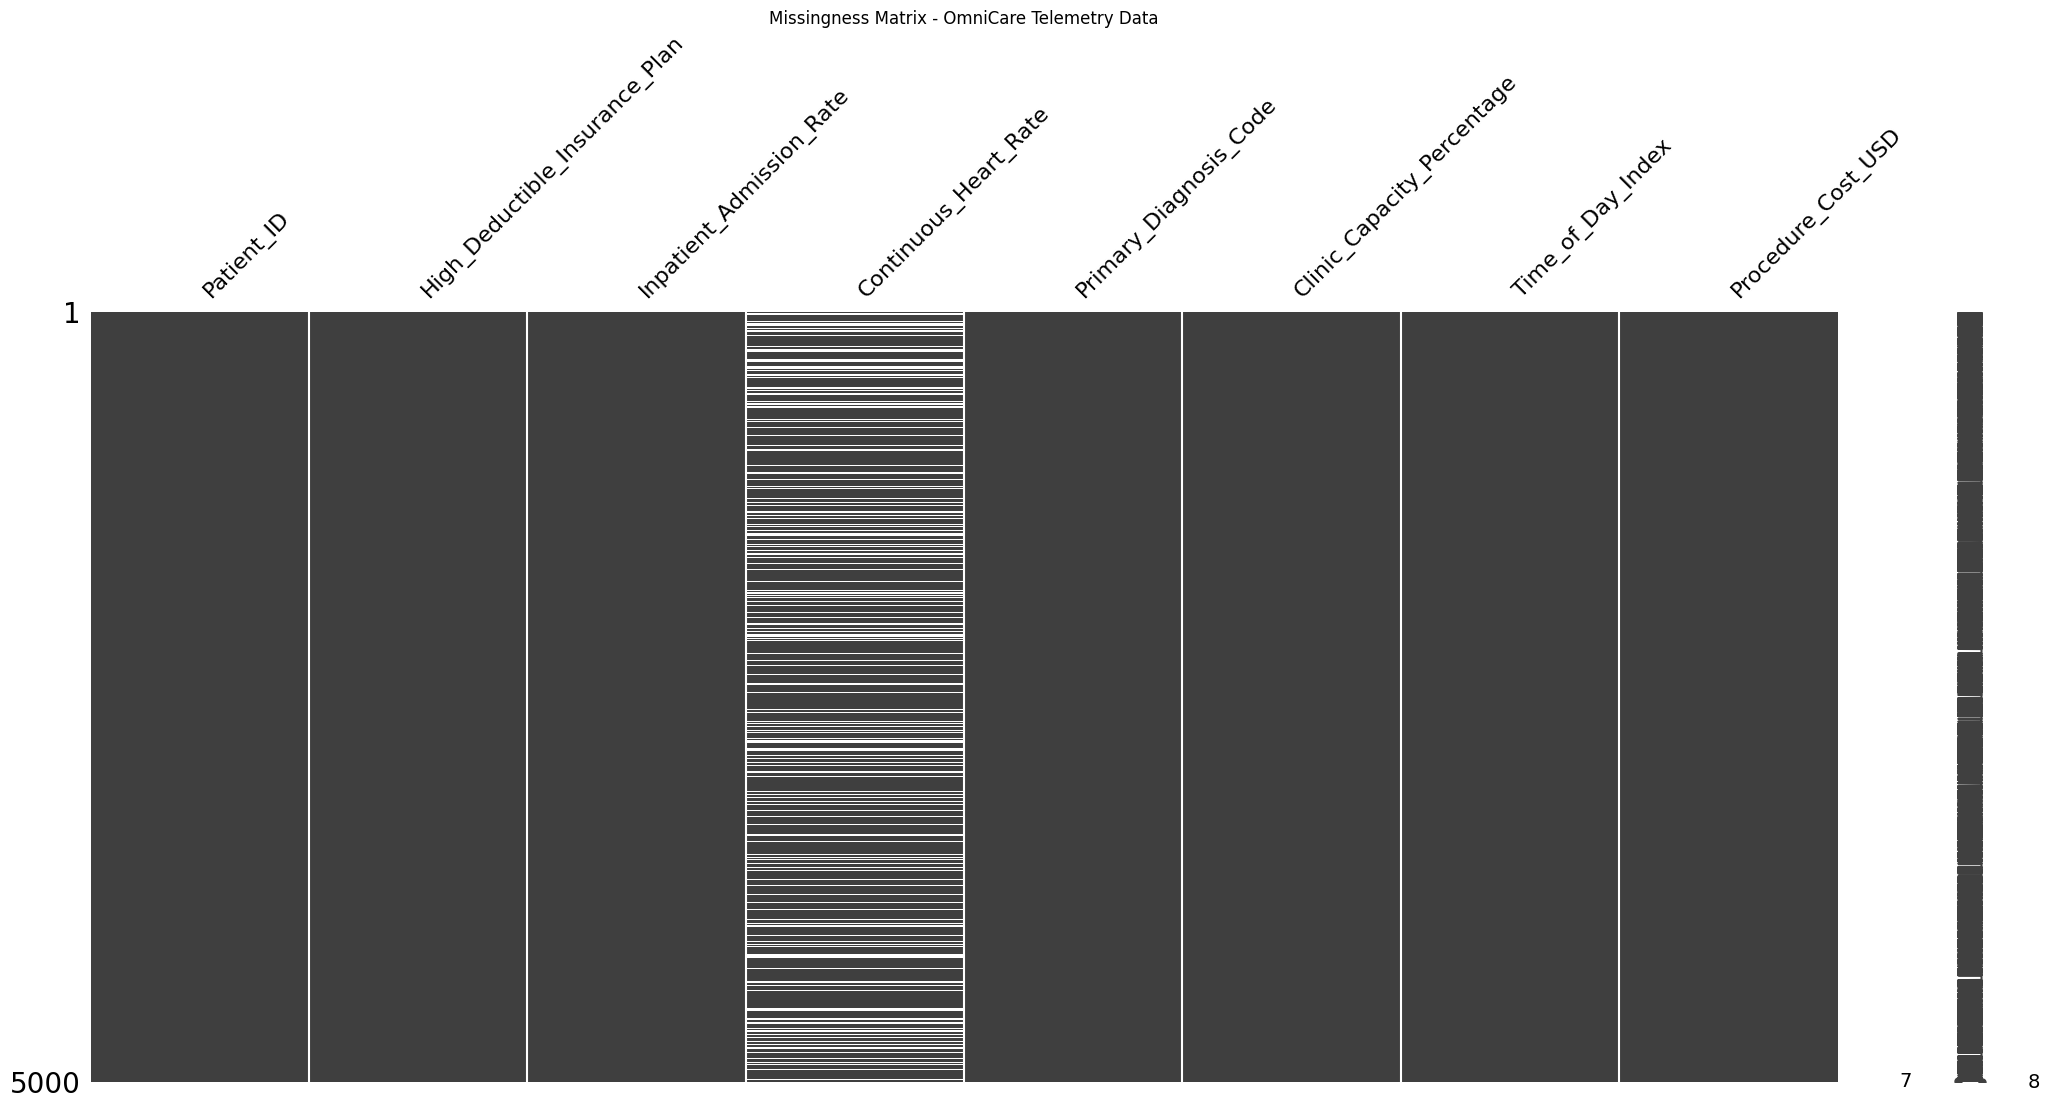

In [9]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
telemetry_df = pd.read_csv("OmniCare_Telemetry_Data.csv")
print(telemetry_df.head())

print("\nMissing values by column:")
print(telemetry_df.isnull().sum())
plt.figure(figsize=(14, 6))
msno.matrix(telemetry_df)
plt.title("Missingness Matrix - OmniCare Telemetry Data")
plt.show()

## Step 2.1: The Architecture of Missingness

The missing values in **Continuous_Heart_Rate** are best classified as **MNAR (Missing Not At Random)**.

### Justification
According to Rubin’s taxonomy:

- **MCAR**: Missingness is completely unrelated to both observed and unobserved data.
- **MAR**: Missingness depends only on observed variables.
- **MNAR**: Missingness depends on the missing mechanism itself or on unobserved factors related to the missing values.

In this case, the gaps occur because **low-income patients systematically refuse to transmit telemetry due to data-plan costs**. This missingness is structurally related to patient economic status and likely also related to health monitoring behavior. Therefore, the probability that heart-rate data is missing is not random.

### Why Mean Imputation is Dangerous
Mean imputation would replace systematically missing heart-rate observations with an artificial average, which would:

1. Understate the true variance of the data  
2. Distort the joint distribution of telemetry signals  
3. Introduce bias by masking the structural differences between patients who transmit and those who do not  
4. Create false clinical stability in a subgroup that is already systematically under-observed  

Therefore, mean imputation would damage the dataset’s integrity and weaken downstream prediction.


## Step 2.2: Escaping the Dummy Variable Trap

Suppose the categorical variable **Primary_Diagnosis_Code** has exactly 850 distinct categories. If a junior analyst applies `pd.get_dummies()` and creates 850 dummy columns, then for every observation exactly one dummy equals 1 and the remaining 849 equal 0.

This implies:

D1 + D2 + ... + D850 = 1

If the regression model also includes an intercept term, then the intercept column is itself a vector of ones:

Intercept = 1

So the design matrix contains a perfect linear dependency:

Intercept = D1 + D2 + ... + D850

Therefore, the columns of the design matrix are linearly dependent, meaning the matrix \(X'X\) is singular and non-invertible.

Since the OLS estimator is:

\[
\hat{\beta} = (X'X)^{-1}X'y
\]

the estimator cannot be computed uniquely when \(X'X\) is singular.

### Conclusion
Including all 850 dummy variables together with a constant intercept creates perfect multicollinearity, known as the **dummy variable trap**, which destroys the OLS estimator mathematically.

In [12]:
!pip install missingno category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.0 MB/s eta 0:00:00


Step 2.3: Target Encoding Implementation

In [13]:
import pandas as pd
from category_encoders import TargetEncoder

telemetry_df = pd.read_csv("OmniCare_Telemetry_Data.csv")
print("Columns:")
print(telemetry_df.columns.tolist())

df_te = telemetry_df[["Primary_Diagnosis_Code", "Procedure_Cost_USD"]].copy()
df_te = df_te.dropna(subset=["Primary_Diagnosis_Code", "Procedure_Cost_USD"])

X = df_te[["Primary_Diagnosis_Code"]]
y = df_te["Procedure_Cost_USD"]

te = TargetEncoder(cols=["Primary_Diagnosis_Code"])
X_encoded = te.fit_transform(X, y)

X_encoded.columns = ["Primary_Diagnosis_Code_TE"]

encoded_result = pd.concat([df_te.reset_index(drop=True), X_encoded.reset_index(drop=True)], axis=1)

print("\nFirst five rows of the encoded continuous vector:")
print(encoded_result.head())

Columns:
['Patient_ID', 'High_Deductible_Insurance_Plan', 'Inpatient_Admission_Rate', 'Continuous_Heart_Rate', 'Primary_Diagnosis_Code', 'Clinic_Capacity_Percentage', 'Time_of_Day_Index', 'Procedure_Cost_USD']

First five rows of the encoded continuous vector:
  Primary_Diagnosis_Code  Procedure_Cost_USD  Primary_Diagnosis_Code_TE
0                J86.381             1635.84                1707.697108
1                M29.789             1355.77                1792.303198
2                E49.618             1189.19                1730.334968
3                E66.244             1250.93                1725.060944
4                J45.553             1986.34                1801.821085


Phase 3

Step 3.1: OLS Optimization via Patsy Formulas

In [16]:
import pandas as pd
import statsmodels.formula.api as smf
from category_encoders import TargetEncoder

telemetry_df = pd.read_csv("OmniCare_Telemetry_Data.csv")
vitals_df = pd.read_csv("OmniCare_Clinical_Vitals.csv")

print("Telemetry columns:")
print(telemetry_df.columns.tolist())
print("\nVitals columns:")
print(vitals_df.columns.tolist())

common_cols = list(set(telemetry_df.columns).intersection(set(vitals_df.columns)))
print("\nCommon columns between the two datasets:")
print(common_cols)
merge_key = "Patient_ID"

df = pd.merge(telemetry_df, vitals_df, on=merge_key, how="inner")

print("\nMerged dataframe shape:", df.shape)
print(df.head())

te = TargetEncoder(cols=["Primary_Diagnosis_Code"])

df["Primary_Diagnosis_Code_TE"] = te.fit_transform(
    df[["Primary_Diagnosis_Code"]],
    df["Procedure_Cost_USD"]
)

print("\nFirst 5 rows of encoded diagnosis:")
print(df[["Primary_Diagnosis_Code", "Primary_Diagnosis_Code_TE"]].head())

final_cols = [
    "Procedure_Cost_USD",
    "Primary_Diagnosis_Code_TE",
    "Clinic_Capacity_Percentage",
    "Time_of_Day_Index",
    "Weight_kg",
    "Height_cm",
    "Systolic_BP",
    "Diastolic_BP"
]

missing_cols = [col for col in final_cols if col not in df.columns]
if missing_cols:
    raise KeyError(f"These columns are missing from merged dataframe: {missing_cols}")

df_model = df[final_cols].dropna()

print("\nFinal modeling dataset shape:", df_model.shape)
print(df_model.head())

formula = """
Procedure_Cost_USD ~ Primary_Diagnosis_Code_TE
+ Clinic_Capacity_Percentage
+ Time_of_Day_Index
+ Weight_kg
+ Height_cm
+ Systolic_BP
+ Diastolic_BP
"""

model = smf.ols(formula=formula, data=df_model).fit()
print("\nOLS Summary:")
print(model.summary())

Telemetry columns:
['Patient_ID', 'High_Deductible_Insurance_Plan', 'Inpatient_Admission_Rate', 'Continuous_Heart_Rate', 'Primary_Diagnosis_Code', 'Clinic_Capacity_Percentage', 'Time_of_Day_Index', 'Procedure_Cost_USD']

Vitals columns:
['Patient_ID', 'Height_cm', 'Weight_kg', 'BMI', 'Systolic_BP', 'Diastolic_BP']

Common columns between the two datasets:
['Patient_ID']

Merged dataframe shape: (5000, 13)
   Patient_ID  High_Deductible_Insurance_Plan  Inpatient_Admission_Rate  \
0        1000                               1                     0.341   
1        1001                               0                     0.213   
2        1002                               0                     0.166   
3        1003                               1                     0.143   
4        1004                               0                     0.219   

   Continuous_Heart_Rate Primary_Diagnosis_Code  Clinic_Capacity_Percentage  \
0                   76.9                J86.381              

## Step 3.2: Financial Loss Quantification (RMSE)

The Root Mean Squared Error (RMSE) measures the average prediction error in absolute dollar terms.

If the typical MRI procedure costs $1,200 and the model produces an RMSE of $450, this implies:

### Operational Risk
The pricing algorithm can deviate by nearly 40% of the actual procedure cost, leading to unstable and unpredictable billing outcomes.

### Financial Risk
- Systematic underpricing → revenue leakage
- Systematic overpricing → patient drop-off and reduced demand
- High volatility → inability to forecast revenue streams

### Regulatory Risk
Healthcare pricing is highly regulated. A pricing error of this magnitude could:
- Trigger compliance violations
- Lead to accusations of price discrimination
- Result in legal penalties and reputational damage

### Conclusion
An RMSE of $450 renders the model unsafe for deployment in a real hospital pricing system.

Step 3.3: Residual Diagnostics for Heteroscedasticity

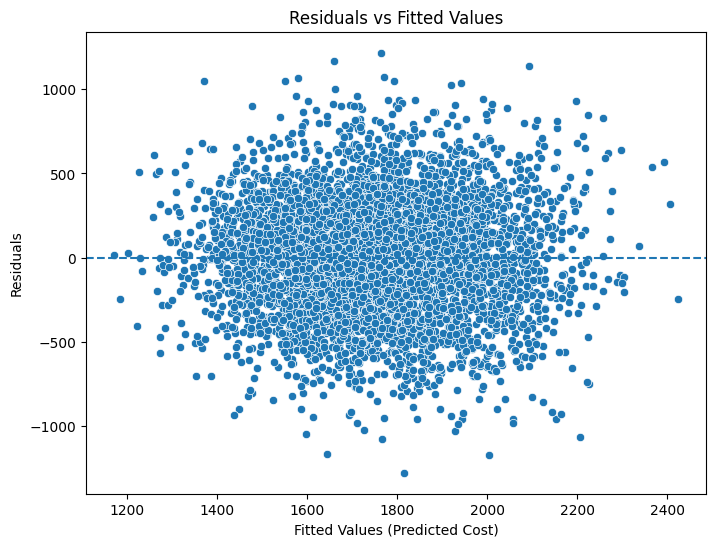

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

fitted_vals = model.fittedvalues
residuals = model.resid
plt.figure(figsize=(8,6))
sns.scatterplot(x=fitted_vals, y=residuals)

plt.axhline(0, linestyle='--')
plt.xlabel("Fitted Values (Predicted Cost)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.show()

Phase 4

In [18]:
# Task 4.1: White's Lagrange Multiplier Test for Heteroscedasticity

from statsmodels.stats.diagnostic import het_white
residuals = model.resid
exog_matrix = model.model.exog

# White test
white_test_results = het_white(residuals, exog_matrix)

labels = ['LM Statistic', 'LM Test p-value', 'F-Statistic', 'F-Test p-value']

print("White's Lagrange Multiplier Test Results")
for label, value in zip(labels, white_test_results):
    print(f"{label}: {value}")
lm_pvalue = white_test_results[1]

print(f"\nLM Test p-value: {lm_pvalue}")

if lm_pvalue < 0.05:
    print("Conclusion: Reject the null hypothesis of homoscedasticity. The model shows evidence of heteroscedasticity.")
else:
    print("Conclusion: Fail to reject the null hypothesis of homoscedasticity. There is insufficient evidence of heteroscedasticity.")

White's Lagrange Multiplier Test Results
LM Statistic: 186.46773970660723
LM Test p-value: 1.4380291432919198e-22
F-Statistic: 5.494188406766981
F-Test p-value: 4.4790231228469927e-23

LM Test p-value: 1.4380291432919198e-22
Conclusion: Reject the null hypothesis of homoscedasticity. The model shows evidence of heteroscedasticity.


## White's Lagrange Multiplier Test for Heteroscedasticity

The results of White’s Lagrange Multiplier Test are as follows:

- LM Statistic: 186.47  
- LM Test p-value: 1.44 × 10⁻²²  
- F-Statistic: 5.49  
- F-Test p-value: 4.48 × 10⁻²³  

### Conclusion

The LM test p-value is extremely small (1.44 × 10⁻²²), which is far below the 0.05 significance level. Therefore, we reject the null hypothesis of homoscedasticity.

This provides strong statistical evidence that the residuals exhibit heteroscedasticity, indicating that the variance of the errors is not constant across observations.